<a href="https://colab.research.google.com/github/ALDO12062004/EDP2/blob/main/M%C3%A9tododeCrank_Nicolson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ECUACION DEL CALOR. Método implícito de Crank-Nicolson

$$\frac{\partial U}{\partial t}=\frac{\partial^2 U}{\partial x^2} \quad 0<x<1$$

Con las codiciones

*   $u=0 \quad \text{ si } \quad x=0, x=1, t \geq 0$
*   $u=1- 4(x-\frac{1}{2})^2 \quad \text{ para } \quad t=0 \quad  0 \leq x \leq 1$

con $ \quad h=0.1 \quad  \text{y}  \quad k=0.01$

---

***Solución:***

En diferencias finitas tenemos un sistema de matrices a partir de la siguiente ecuación:

$$-rU_{i-1,j+1} + (2+2r)U_{i,j+1} - rU_{i+1,j+1}=rU_{i-1,j} + (2-2r)U_{i,j} + rU_{i+1,j}$$

con $$\quad r=\alpha^2 \frac{k}{h^2}$$

Que al reducirlo se obtiene un sistema de matrices de la forma $AX=b$ donde $A$ es una matriz tridiagonal

Y se resuelve el sistema aplicando el método de Thomas


In [ ]:
import sympy as sp
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from tabulate import tabulate

Se importan las librerias unmpy y sympy para hacer los cálculos necesarios y definir funciones, así como para aplicar la factorización LU.
Mientras que el resto a excepción de tabulate (que es para poner la solución en una tabla) son para graficar.

In [ ]:
def f(x):
    return 1-4*(x-0.5)**2

Definimos la condición inicial $f(x)=1-4(x-\frac{1}{2})^2$ en el tiempo $t=0$

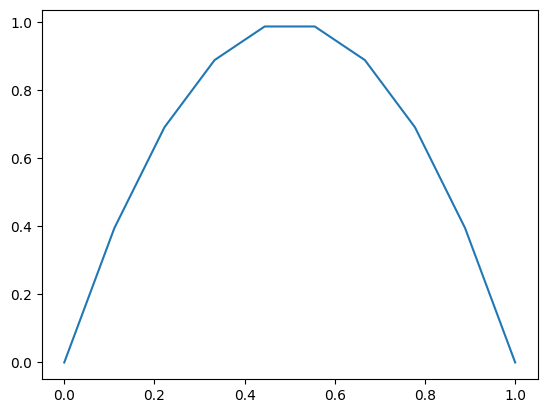

In [ ]:
x = np.linspace(0,1,10)
plt.plot(x,f(x))

Gráfica de la condición inicial usando 10 puntos

In [ ]:
def trifiagonal(n,a,b):
    return sp.Matrix([
    [a if i == j else b if abs(i-j) == 1 else 0 for j in range(n)]
    for i in range(n)
])

Función para llenar una matriz tridiagonal de tamaño n dando como valores de entrada a, b y n, donde a es la diagonal y b son las diagonales superior e inferior

In [ ]:
alpha=1
h=0.1
k=0.01
r=alpha**2 * (k/h**2)
n=9
a=2+2*r
b=-r
A = trifiagonal(n,a,b)

Definimos los escalares que requiere el problema inicialmente para calcular los valores de la diagonal principal, inferior y superior

In [ ]:
A

Matrix([
[ 4.0, -1.0,    0,    0,    0,    0,    0,    0,    0],
[-1.0,  4.0, -1.0,    0,    0,    0,    0,    0,    0],
[   0, -1.0,  4.0, -1.0,    0,    0,    0,    0,    0],
[   0,    0, -1.0,  4.0, -1.0,    0,    0,    0,    0],
[   0,    0,    0, -1.0,  4.0, -1.0,    0,    0,    0],
[   0,    0,    0,    0, -1.0,  4.0, -1.0,    0,    0],
[   0,    0,    0,    0,    0, -1.0,  4.0, -1.0,    0],
[   0,    0,    0,    0,    0,    0, -1.0,  4.0, -1.0],
[   0,    0,    0,    0,    0,    0,    0, -1.0,  4.0]])

Matriz A obtenida a partir de la ecuación de diferencias finitas una vez ya aplicados los valores para cada constante

In [ ]:
B = trifiagonal(9,2-2*r,r)

Matriz tridiagonal B que son valores ya conocidos a partir de los cuales se resolverá el sistema, de igual forma se obtiene de la ecuación de diferencias finitas

In [ ]:
b = sp.Matrix([f(0.1*(i+1)) for i in range(9)])

vector b que corresponde a los valores en el tiempo $t=0$

In [ ]:
b

Matrix([
[0.36],
[0.64],
[0.84],
[0.96],
[ 1.0],
[0.96],
[0.84],
[0.64],
[0.36]])

In [ ]:
def crank_nicolson(A,B,b,j):
    b_1 = B*b #Es la forma de obtener los valores del lado derecho de la ecuación de diferencias finitas B*b
    S = []
    for i in range(j):
        sol= A.LUsolve(b_1)
        S.append(sol.T) #El .T transpone el vector y lo guarda en S
        b_1 = B*sol
    return sp.Matrix(S)

Se define la función general para resolver la ecuación del calor con el método de Crank- Nicolson ya implementando el método de Thomas con factorización LU

In [ ]:
j=50

Damos el número de iteraciones que hara, en $t$ se mueve de $0.01$ por lo que 50 iteraciones llega a $t=0.5$

In [ ]:
U = crank_nicolson(A,B,b,j)

Llamamos a la función crank- nicolson dando como entrada la matriz A,B y el vector b con 50 iteraciones

In [ ]:
data = []
for i in range(0,10):
    fila_act = list(U.row(i)) #Obtiene la fila i-ésima de la matriz U usando U.row(i) y la convierte en una lista
    fila_act.append((i+1) * k) #para agregar la columna adicional de t
    data.append(fila_act) #agrega la columna al data

headers = [f'x{idx+1}' for idx in range(len(data[0]) - 1)] #para los encabezados mide el tamaño de data pero le resta 1 que será t
headers.append('t') #agrega t coo último encabezado
print(tabulate(data, headers=headers, tablefmt="grid")) #imprime la tabla usando tabulate

+----------+----------+----------+----------+----------+----------+----------+----------+----------+------+
|       x1 |       x2 |       x3 |       x4 |       x5 |       x6 |       x7 |       x8 |       x9 |    t |
+==========+==========+==========+==========+==========+==========+==========+==========+==========+======+
| 0.301436 | 0.565746 | 0.761547 | 0.880442 | 0.920221 | 0.880442 | 0.761547 | 0.565746 | 0.301436 | 0.01 |
+----------+----------+----------+----------+----------+----------+----------+----------+----------+------+
| 0.26763  | 0.504776 | 0.688489 | 0.802994 | 0.841718 | 0.802994 | 0.688489 | 0.504776 | 0.26763  | 0.02 |
+----------+----------+----------+----------+----------+----------+----------+----------+----------+------+
| 0.23989  | 0.454784 | 0.623126 | 0.729952 | 0.766473 | 0.729952 | 0.623126 | 0.454784 | 0.23989  | 0.03 |
+----------+----------+----------+----------+----------+----------+----------+----------+----------+------+
| 0.21645  | 0.411015 | 0.56

En la tabla se muestran las primeras 10 iteraciones, es decir para $t=0.1$

In [ ]:
U_np = np.array(U.tolist(), dtype= float)

Se define U_np que es un arreglo para hacer del tipo float a los valores de la lista U

In [ ]:
x = np.linspace(0, 1, 9)
y = np.linspace(0, 0.5, j)
X, Y = np.meshgrid(x, y)

Para las gráficas se definen los parametros de los ejes x,y y sus puntos que tendrán

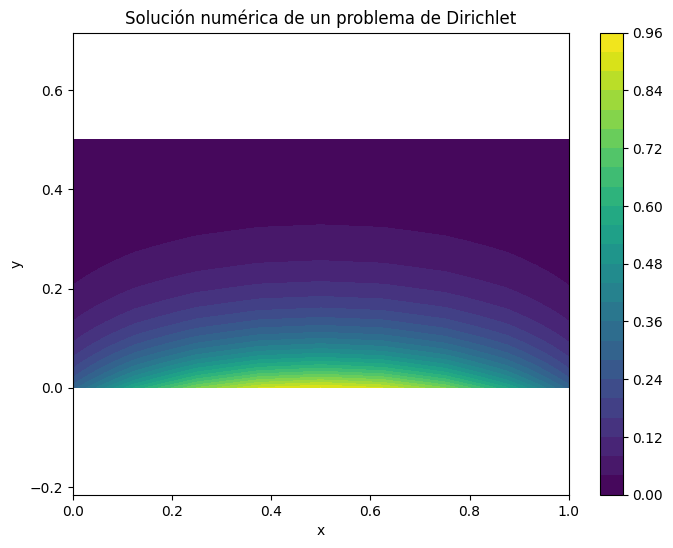

In [ ]:
# Mapa de colores
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, U_np, levels=25, cmap=cm.viridis)
plt.colorbar(contour)
plt.title('Solución numérica de un problema de Dirichlet')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

Gráfica de mapa de colores de la solución de U para 50 iteraciones
Se aprecian los arcos o parabolas de la ecuaicón de calor a través del tiempo

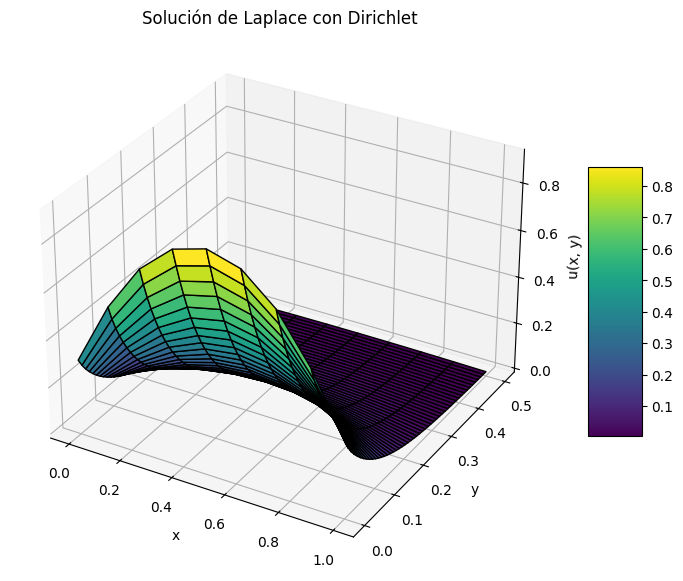

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U_np, cmap=cm.viridis, edgecolor='k')
ax.set_title('Solución de Laplace con Dirichlet')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

En esta gráfica 3D se ve el porque se ven como arcos, es porque al pasar el tiempo la función va decreciendo o mejor dicho el calor se va dispersando

# EJERCICIO 2

Use su código para graficar en un mismo panel su solución numérica y la solución real. Determine el error de su solución.

La solución exacta de la ecuación de calor es:

$$u(x,t)=\Sigma_{n=0}^\infty\frac{32}{[(2n+1)\pi]^3}sin((2n+1)\pi x)e^{-(2n+1)^2\pi^2t}$$

In [ ]:
def u_exact(x,t):
  s_1=0
  for k in range(5):
    n=2*k+1 #Se define de esta manera ya que la solución es para impares
    bn= 32/((n*np.pi)**3)
    s_1 += bn* np.sin(n*np.pi*x) * np.exp(-n**2*np.pi**2*t)
  return s_1

La solución exacta se escribe a manera de función para poder graficarla

In [ ]:
x=np.linspace(0,1,100)
y=np.linspace(0,0.1,11)
X,Y=np.meshgrid(x,y)

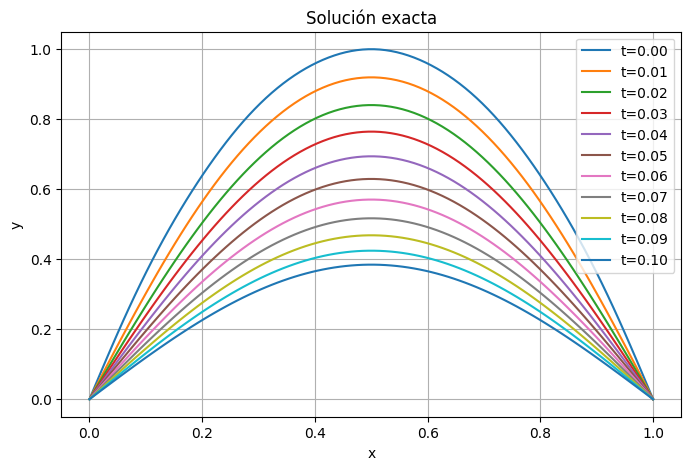

In [ ]:
plt.figure(figsize=(8,5))

for t in y:
  plt.plot(x,u_exact(x,t), label=f"t={t:.2f}")

plt.title("Solución exacta")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la solución exacta para los valores de t de 0 a 0.1

In [ ]:
j=10
U = crank_nicolson(A,B,b,j)

Llamamos a la función U para j=10 para comparar con la gráfica anterior

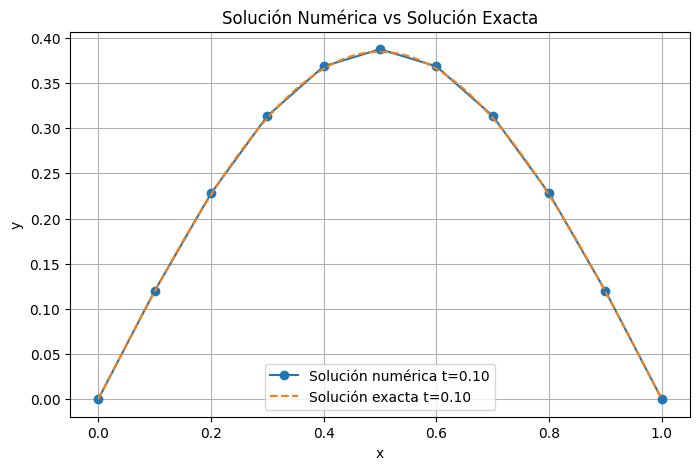

In [ ]:
# Crear malla de puntos x1 según el tamaño de la solución (nodos interiores)
n = U.shape[1]  # número de incógnitas
x_num = np.linspace(h, 1-h, n) #los puntos comienzan en h=0.1 y terminan en 1-h=0.9
x_ex = np.linspace(0,1,200)  # malla fina para la solución exacta

# Agregar puntos de frontera para la solución numérica
x_completo = np.concatenate(([0], x_num, [1])) #para incluir las fronteras x=0 y x=1
U_completo = np.concatenate(([0], U.row(j-1).tolist()[0], [0])) #valor de u(0,t)=u(1,t)=0, y se toma la última fila (j-1)

plt.figure(figsize=(8,5))
plt.plot(x_completo, U_completo, 'o-', label=f'Solución numérica t={j*k:.2f}') # Solución numérica
plt.plot(x_ex, u_exact(x_ex, j*k), '--', label=f'Solución exacta t={j*k:.2f}') # Solución exacta
plt.title('Solución Numérica vs Solución Exacta')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Comparativa en $t=0.1$ nótese que es muy parecida, el error es pequeño

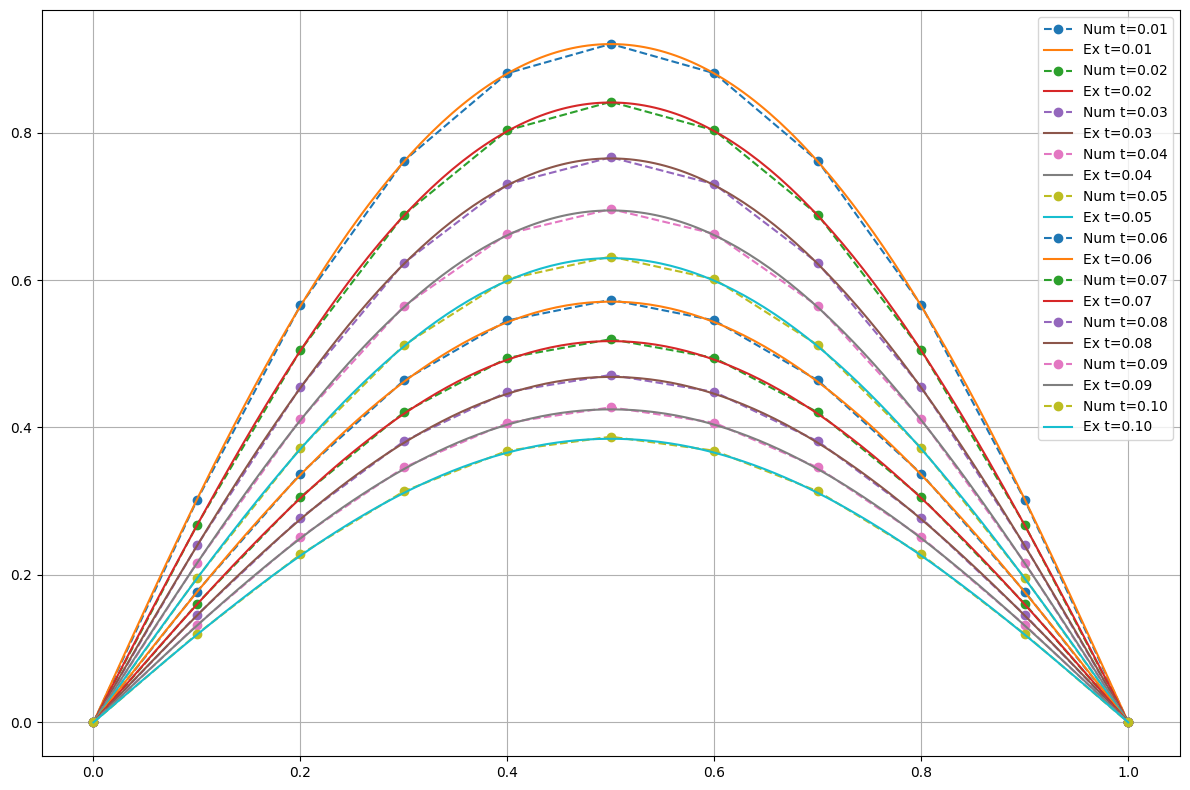

In [ ]:
# Crear malla de puntos x1 según el tamaño de la solución (nodos interiores)
n = U.shape[1]  # número de incógnitas
x_num = np.linspace(h, 1-h, n) #los puntos comienzan en h=0.1 y terminan en 1-h=0.9
x_ex = np.linspace(0,1,200) #para solucióin exacta

# Agregar puntos de frontera para la solución numérica
x_completo = np.concatenate(([0], x_num, [1])) #para incluir las fronteras x=0 y x=1
plt.figure(figsize=(12, 8)) #Para hacer la gráfica más grande y se noten las comparativas

for i in range(j):
    t_act = (i + 1) * k #variación de los t

    #Solución numérica
    U_fila_act = U.row(i).tolist()[0] # sacamos la información de la lista U para iterar
    U_completo_act = np.concatenate(([0], U_fila_act, [0])) # Para agregar las fronteras en cada iteración
    plt.plot(x_completo, U_completo_act, 'o--', label=f'Num t={t_act:.2f}')

    # Solución exacta
    plt.plot(x_ex, u_exact(x_ex, t_act), '-', label=f'Ex t={t_act:.2f}')

plt.legend()
plt.grid(True)
plt.tight_layout() #Ajusta las dimensiones de la gráfica
plt.show()

Aquí se aprecia la comparativa de la solución exacta con la numérica, donde se ve que es una muy buena aproximación para $t=0.1,...,1$

In [ ]:
norm = []

for i in range(j):
    t_act = (i + 1) * k #variación de los t

    U_fila_act = np.array(U.row(i).tolist()[0], dtype=float) #Solución numérica

    u_exact_act = np.array(u_exact(x_num, t_act), dtype=float) #Solución exacta

    dif = U_fila_act - u_exact_act #Diferencia de vectores para cada t

    l2_norm = np.linalg.norm(dif) #Norma 2 de cada vector t
    norm.append(l2_norm)

print("Error:")
for i, norm_val in enumerate(norm):
    print(f"t={(i+1)*k:.2f}: {norm_val:.6f}")

Error:
t=0.01: 0.002584
t=0.02: 0.002732
t=0.03: 0.003702
t=0.04: 0.004490
t=0.05: 0.005100
t=0.06: 0.005557
t=0.07: 0.005884
t=0.08: 0.006101
t=0.09: 0.006225
t=0.10: 0.006273


De cada vector obtenido en cada paso t se resta el de la solución aproximada con el de la solución numérica y se obtienen 10 vectores a los cuales se calcula la norma 2 para saber el error de cada piso (valor de t)